In [4]:
import sys

sys.executable, sys.version

('/workspace/ViCLIP-OT/.venv/bin/python3',
 '3.12.13 (main, May 10 2026, 19:30:01) [Clang 22.1.3 ]')

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
%cd /workspace/ViCLIP-OT

/workspace/ViCLIP-OT


## Import libraries

In [7]:
import os
import textwrap
from typing import Literal

import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import scienceplots  # noqa: F401
import torch
import torchvision.transforms.v2 as v2
from matplotlib.gridspec import GridSpec
from PIL import Image
from tqdm.autonotebook import tqdm

import viclip_ot.constants as C
import viclip_ot.utils as utils
from viclip_ot.dataset import ImageTextDataset
from viclip_ot.model import ViCLIPOT, ViCLIPOTConfig
from viclip_ot.utils.logger import logger

/tmp/ipykernel_3379/895447377.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Config

In [8]:
SEED = 42
DATASET_DIR = "./data/UIT-OpenViIC"
TEST_SPLIT_NAME = "test"
VISIGLIP_OT_CONFIG_FILE = "./config/model.vit_base_dinov3_sbert_siglip.yaml"
SIGLIP_CONFIG_FILE = "./config/model.vit_base_dinov3_sbert_siglip.yaml"

VISIGLIP_OT_CHECKPOINT = "./checkpoints/visiglip_ot/visiglip_ot.pth"
SIGLIP_CHECKPOINT = "./checkpoints/siglip/siglip.pth"

DEVICE = "auto"

## Loading model

In [9]:
utils.set_seed(SEED)
device = utils.get_device(DEVICE)
print(f"Using device: {device}")

Using device: cuda


In [10]:
model_config1 = ViCLIPOTConfig.model_validate(utils.load_yaml_file(VISIGLIP_OT_CONFIG_FILE))
print(f"Model config: {model_config1}")
model1 = ViCLIPOT(config=model_config1)
tokenizer1 = model1.text_encoder.tokenizer
model1.to(device).eval()
print(f"{model1.training}")

model_config2 = ViCLIPOTConfig.model_validate(utils.load_yaml_file(SIGLIP_CONFIG_FILE))
print(f"Model config: {model_config2}")
model2 = ViCLIPOT(config=model_config2)
tokenizer2 = model2.text_encoder.tokenizer
model2.to(device).eval()
print(f"{model2.training}")

Model config: image_config=ViCLIPOTImageConfig(model_name='timm/vit_base_patch16_dinov3.lvd1689m', pretrained=True, pool='avg', proj='linear', proj_bias=False, proj_dropout_rate=0.1) text_config=ViCLIPOTTextConfig(model_name='keepitreal/vietnamese-sbert', pretrained=True, proj='none', proj_bias=False) embed_dim=768 max_length=256 initial_temperature=0.06 logit_bias=-9.0
False
Model config: image_config=ViCLIPOTImageConfig(model_name='timm/vit_base_patch16_dinov3.lvd1689m', pretrained=True, pool='avg', proj='linear', proj_bias=False, proj_dropout_rate=0.1) text_config=ViCLIPOTTextConfig(model_name='keepitreal/vietnamese-sbert', pretrained=True, proj='none', proj_bias=False) embed_dim=768 max_length=256 initial_temperature=0.06 logit_bias=-9.0
False


In [11]:
logger.info(f"Loading model from checkpoint: {VISIGLIP_OT_CHECKPOINT}")
checkpoint = torch.load(VISIGLIP_OT_CHECKPOINT, map_location=device, weights_only=False)
model1.load_state_dict(checkpoint["model_state_dict"], strict=True)

logger.info(f"Loading model from checkpoint: {SIGLIP_CHECKPOINT}")
checkpoint = torch.load(SIGLIP_CHECKPOINT, map_location=device, weights_only=False)
model2.load_state_dict(checkpoint["model_state_dict"], strict=True)

2026-05-18 09:06:56.579 | INFO     | __main__:<module>:1 - Loading model from checkpoint: ./checkpoints/visiglip_ot/visiglip_ot.pth


2026-05-18 09:06:56.953 | INFO     | __main__:<module>:5 - Loading model from checkpoint: ./checkpoints/siglip/siglip.pth


<All keys matched successfully>

## Loading test data

In [12]:
eval_transforms = v2.Compose(
    [
        v2.Resize(size=256, interpolation=v2.InterpolationMode.BICUBIC),
        v2.CenterCrop(size=224),
        v2.ToTensor(),
        v2.Normalize(
            mean=C.IMAGENET_DEFAULT_MEAN,
            std=C.IMAGENET_DEFAULT_STD,
        ),
    ]
)


def model_fmt(model_config) -> Literal["gemma", "e5", "qwen3", "bge", "sbert"]:
    model_name = model_config.text_config.model_name
    if "gemma" in model_name.lower():  # google/embeddinggemma-300m
        return "gemma"
    elif "e5" in model_name.lower():  # intfloat/multilingual-e5-large
        return "e5"
    elif "qwen" in model_name.lower():  # Qwen/Qwen3-Embedding-0.6B
        return "qwen3"
    elif "bge" in model_name.lower():  # BAAI/bge-m3
        return "bge"
    elif "sbert" in model_name.lower():  # keepitreal/vietnamese-sbert
        return "sbert"
    else:
        raise ValueError(f"Unsupported model name for determining model format: {model_name}")


assert model_config1.text_config.model_name == model_config2.text_config.model_name, (
    "Both models must use the same text encoder model."
)
logger.info(f"Determined model format: {model_fmt(model_config1)}")

test_dataset = ImageTextDataset(
    root_dir=DATASET_DIR,
    metadata_json_file=f"{TEST_SPLIT_NAME}.json",
    image_transforms=eval_transforms,
    model_fmt=model_fmt(model_config1),
)

/workspace/ViCLIP-OT/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
2026-05-18 09:06:59.047 | INFO     | __main__:<module>:33 - Determined model format: sbert
2026-05-18 09:06:59.048 | INFO     | viclip_ot.dataset:__init__:77 - Loading image text data from: ./data/UIT-OpenViIC/test.json
2026-05-18 09:06:59.078 | INFO     | viclip_ot.dataset:__init__:81 - Found 1998 images and 9986 annotations.


## Visualizing retrieval examples

### 0. Embedding images

In [16]:
all_image_features = ([], [])
all_sample_image_indices = []
batch_size = 64
with torch.no_grad():
    progress_bar = tqdm(range(0, len(test_dataset), batch_size), "Computing image embeddings")
    for start_idx in progress_bar:
        end_idx = min(len(test_dataset), start_idx + batch_size)

        images = []
        for j in range(start_idx, end_idx):
            sample = test_dataset[j]
            images.append(sample[0])
            all_sample_image_indices.append(sample[3])

        images = torch.stack(images).to(device)

        image_features1 = model1.encode_image(images, normalize=True)
        image_features2 = model2.encode_image(images, normalize=True)

        all_image_features[0].append(image_features1.cpu())
        all_image_features[1].append(image_features2.cpu())

    all_image_features = (
        torch.cat(all_image_features[0], dim=0),
        torch.cat(all_image_features[1], dim=0),
    )

print(f"{all_image_features[0].shape = }")
print(f"{all_image_features[1].shape = }")

Embedding images:   0%|          | 0/32 [00:00<?, ?it/s]

all_image_features[0].shape = torch.Size([1998, 768])
all_image_features[1].shape = torch.Size([1998, 768])


### 1. Text to image retrieval

#### 1.1 Computing text query embeddings

In [17]:
text_queries = [
    # "Phở",
    # "Một Cô gái mặc Áo dài và nón lá đi trong một con phố cổ",
    "Hoàng hôn bên bờ sông",
    "Một Cô gái mặc áo dài màu đỏ",
    # "Phố cổ vào ban đêm",
    "Phố cổ với nhiều lồng đèn xung quanh",
    # "Thuyền trên sông lúc hoàng hôn",
    # "Trẻ em chơi đùa trên bãi biển",
    # "Khu vực Chợ nổi Cái Răng đông đúc",
    # "Một ngọn tháp nằm giữa hồ",
    # "Nhiều người đang tập trung xung quanh một ngôi chùa",
    # "Ngôi nhà cổ màu vàng",
    # "Nhà thờ nhìn từ trên cao",
    # "Một người phụ nữ đang gánh hàng rong",
    # "Khu vực hồ nhìn từ trên cao",
    "Một khu phố cổ bên cạnh một dòng sông",
]
translated_queries = [
    # "Pho",
    # "A girl in Ao dai and Non la walking in an old quarter",
    "Sunset by the river",
    "A girl in a red Ao dai",
    # "Old Quarter at night",
    "Old town with many lanterns around",
    # "Boat on the river at sunset",
    # "Children playing on the beach",
    # "A bustling Cai Răng Floating Market area",
    # "A tower in the middle of a lake",
    # "Many people gathering around a temple",
    # "An old yellow house",
    # "A church seen from above",
    # "A woman carrying street food",
    # "A lake area seen from above",
    "An old quarter beside a river",
]

all_text_features = ([], [])
batch_size = 32
with torch.no_grad():
    progress_bar = tqdm(range(0, len(text_queries), batch_size), "Embedding text")
    for start_idx in progress_bar:
        end_idx = min(len(text_queries), start_idx + batch_size)
        text_inputs1 = tokenizer1(
            [query.lower() for query in text_queries[start_idx:end_idx]],
            padding=True,
            truncation=True,
            max_length=2048,
            return_tensors="pt",
        ).to(device)

        text_inputs2 = tokenizer2(
            [query.lower() for query in text_queries[start_idx:end_idx]],
            padding=True,
            truncation=True,
            max_length=2048,
            return_tensors="pt",
        ).to(device)

        text_features1 = model1.encode_text(text_inputs1, normalize=True)
        text_features2 = model2.encode_text(text_inputs2, normalize=True)

        all_text_features[0].append(text_features1.cpu())
        all_text_features[1].append(text_features2.cpu())

    all_text_features = (
        torch.cat(all_text_features[0], dim=0),
        torch.cat(all_text_features[1], dim=0),
    )

print(f"{all_text_features[0].shape = }")
print(f"{all_text_features[1].shape = }")

Embedding text:   0%|          | 0/1 [00:00<?, ?it/s]

all_text_features[0].shape = torch.Size([4, 768])
all_text_features[1].shape = torch.Size([4, 768])


In [18]:
logits_t2i = (
    all_text_features[0] @ all_image_features[0].t(),
    all_text_features[1] @ all_image_features[1].t(),
)
print(f"{logits_t2i[0].shape = }")
print(f"{logits_t2i[1].shape = }")

logits_t2i[0].shape = torch.Size([4, 1998])
logits_t2i[1].shape = torch.Size([4, 1998])


#### 1.2 Plot text to image retrieval results

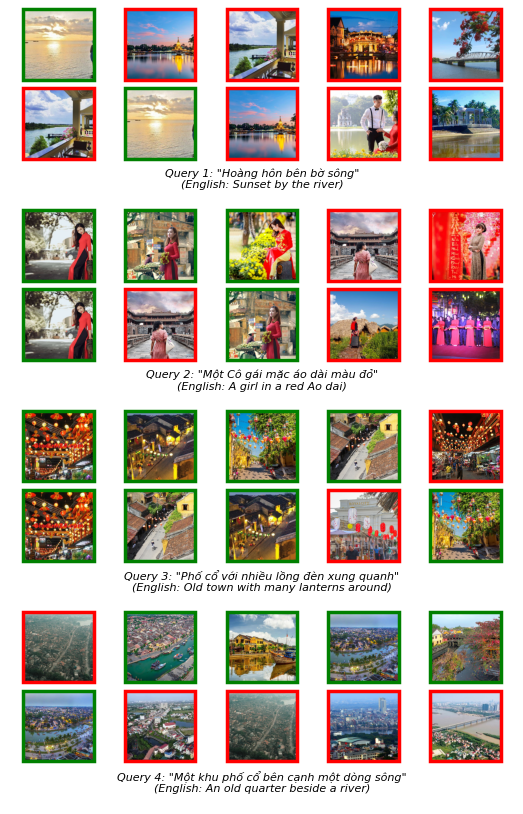

In [19]:
np.random.seed(SEED)
num_queries = len(text_queries)
top_k = 5
query_indices = np.random.choice(len(all_text_features[0]), size=num_queries, replace=False)

# Model names for labeling
model_names = ["ViSigLIP-OT", "SigLIP"]

# Whether to draw annotation borders on retrieved images
draw_annotations = True

# Set of (query_idx, model_idx, rank) tuples marking correct retrievals (green border).
# All other images get a red border when draw_annotations is True.
# query_idx: 0-based index into text_queries
# model_idx: 0 = SigLIP-SIGROT, 1 = SigLIP
# rank: 0-based rank in top-k results (0 = highest similarity)
correct_retrievals: set[tuple[int, int, int]] = {
    (0, 0, 0),
    (0, 1, 1),
    (1, 0, 0),
    (1, 0, 1),
    (1, 0, 2),
    (1, 1, 0),
    (1, 1, 2),
    (2, 0, 0),
    (2, 0, 1),
    (2, 0, 2),
    (2, 0, 3),
    (2, 1, 0),
    (2, 1, 1),
    (2, 1, 2),
    (2, 1, 4),
    (3, 0, 1),
    (3, 0, 2),
    (3, 0, 3),
    (3, 0, 4),
    (3, 1, 0),
}

# Figure dimensions for elsarticle preprint (text width ~6.5 inches)
fig_width = 6.5  # inches, suitable for single-column preprint
img_aspect_ratio = 1  # width/height ratio for displayed images (square)
img_width = fig_width / top_k  # width per image
img_height = img_width / img_aspect_ratio * 0.8  # reduced height to fit 2 model rows per query
query_text_space = 0.5  # space for query text below images

# 3 rows per query: model 1 images, model 2 images, query text
rows_per_query = 3
height_ratios_per_query = [img_height, img_height, query_text_space]
fig_height = (img_height * 2 + query_text_space) * num_queries

# Create figure with GridSpec for better control
fig = plt.figure(figsize=(fig_width, fig_height))
gs = GridSpec(
    num_queries * rows_per_query,
    top_k,  # 3 rows per query: model1, model2, text
    figure=fig,
    height_ratios=height_ratios_per_query * num_queries,
    hspace=0.15,
    wspace=0.05,
)

for query_row, query_idx in enumerate(range(len(query_indices))):
    query_text = text_queries[query_idx]

    # Display results for each model
    for model_idx in range(2):
        similarities = logits_t2i[model_idx][query_idx]

        # Get top-k indices sorted by decreasing similarity
        top_k_indices = torch.argsort(similarities, descending=True)[:top_k]
        top_k_scores = similarities[top_k_indices]

        # Calculate the grid row for this model's images
        grid_row = query_row * rows_per_query + model_idx

        # Display top-k retrieved images with consistent dimensions
        for col, (img_idx, score) in enumerate(zip(top_k_indices, top_k_scores, strict=True)):
            img_idx = img_idx.item()

            # Get the image from dataset using unique_image_ids mapping
            image_path = test_dataset.samples[all_sample_image_indices[img_idx]][1]  # pyright: ignore
            image = mpimg.imread(image_path)

            # Create axes for image
            ax = fig.add_subplot(gs[grid_row, col])

            # Center crop image to square for consistent display
            h, w = image.shape[:2]
            min_dim = min(h, w)
            start_h = (h - min_dim) // 2
            start_w = (w - min_dim) // 2
            cropped_image = image[start_h : start_h + min_dim, start_w : start_w + min_dim]

            ax.imshow(cropped_image)
            ax.axis("off")

            # Draw colored border: green if correct, red otherwise.
            # Uses a Rectangle patch since ax.axis("off") suppresses spine rendering.
            if draw_annotations:
                border_color = (
                    "green" if (query_idx, model_idx, col) in correct_retrievals else "red"
                )
                rect = patches.Rectangle(
                    (0, 0),
                    1,
                    1,
                    linewidth=2.5,
                    edgecolor=border_color,
                    facecolor="none",
                    transform=ax.transAxes,
                    clip_on=False,
                )
                ax.add_patch(rect)

    # Create a spanning axes for query text below both model rows
    text_grid_row = query_row * rows_per_query + 2
    ax_text = fig.add_subplot(gs[text_grid_row, :])
    ax_text.axis("off")

    # Display query text centered below the images
    # y=1.0 places text at top of text area (close to images above)
    wrapped_text = textwrap.fill(query_text, width=60)
    translated_text = translated_queries[query_idx]
    ax_text.text(
        0.5,
        1.0,
        f'Query {query_row + 1}: "{wrapped_text}"\n(English: {translated_text})',
        ha="center",
        va="top",
        fontsize=8,
        style="italic",
        transform=ax_text.transAxes,
    )

plt.savefig("t2i_retrieval_examples_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

### 2. Image to image retrieval

#### 2.1 Computing image query embeddings

In [20]:
# image from test set
image_query_files = [
    # "00000000763.jpg",  # query 1
    # "00000000728.jpg",  # query 2
    # "00000010187.jpg",  # query 3
    "00000010186.jpg",  # query 4
    "00000010160.jpg",  # query 5
    # "00000010136.jpg",  # query 6
    # "00000009976.jpg",  # query 7
    # "00000009935.jpg",  # query 8
    # "00000009913.jpg",  # query 9
    # "00000009812.jpg",  # query 10
    # "00000009680.jpg",  # query 11
    # "00000009621.jpg",  # query 12
    # "00000009616.jpg",  # query 13
    # "00000009349.jpg",  # query 14
    # "00000009336.jpg",  # query 15
    "00000009318.jpg",  # query 16
    # "00000009177.jpg",  # query 17
    # "00000008793.jpg",  # query 18
    # "00000008790.jpg",  # query 19
    # "00000006092.jpg",  # query 20
    # "00000006093.png",  # query 21
    # "00000006096.jpg",  # query 22
    # "00000006902.jpg",  # query 23
    # "00000006907.jpg",  # query 24
    "00000006914.jpg",  # query 25
    # "00000006920.jpg",  # query 26
    # "00000006939.jpg",  # query 27
    # "00000006971.jpg",  # query 28
    # "00000006975.jpg",  # query 29
    # "00000007416.jpg",  # query 30
    # "00000007446.jpg",  # query 31
    # "00000007448.jpg",  # query 32
    # "00000007452.jpg",  # query 33
    # "00000007478.jpg",  # query 34
    # "00000007493.jpg",  # query 35
    # "00000007713.jpg",  # query 36
]

image_query_file_paths = [os.path.join(DATASET_DIR, "images", f) for f in image_query_files]

all_image_query_features = ([], [])
batch_size = 32
with torch.no_grad():
    progress_bar = tqdm(range(0, len(image_query_file_paths), batch_size), "Embedding image query")
    for start_idx in progress_bar:
        end_idx = min(len(image_query_file_paths), start_idx + batch_size)

        images = []
        for j in range(start_idx, end_idx):
            image_path = image_query_file_paths[j]
            try:
                image = Image.open(image_path)
                # handle palette images with transparency
                if image.mode == "P" and "transparency" in image.info:
                    image = image.convert("RGBA")

                image = image.convert("RGB")

            except (OSError, SyntaxError) as e:
                raise RuntimeError(f"Error opening image file {image_path}: {e}")

            image = eval_transforms(image)
            images.append(image)

        image_inputs = torch.stack(images).to(device)
        image_features1 = model1.encode_image(image_inputs, normalize=True)
        image_features2 = model2.encode_image(image_inputs, normalize=True)

        all_image_query_features[0].append(image_features1.cpu())
        all_image_query_features[1].append(image_features2.cpu())
    all_image_query_features = (
        torch.cat(all_image_query_features[0], dim=0),
        torch.cat(all_image_query_features[1], dim=0),
    )

print(f"{all_image_query_features[0].shape = }, {all_image_query_features[1].shape = }")

Embedding image query:   0%|          | 0/1 [00:00<?, ?it/s]

all_image_query_features[0].shape = torch.Size([4, 768]), all_image_query_features[1].shape = torch.Size([4, 768])


In [21]:
logits_i2i = (
    all_image_query_features[0] @ all_image_features[0].t(),
    all_image_query_features[1] @ all_image_features[1].t(),
)
print(f"{logits_i2i[0].shape = }, {logits_i2i[1].shape = }")

logits_i2i[0].shape = torch.Size([4, 1998]), logits_i2i[1].shape = torch.Size([4, 1998])


#### 2.2 Plot image to image retrieval results

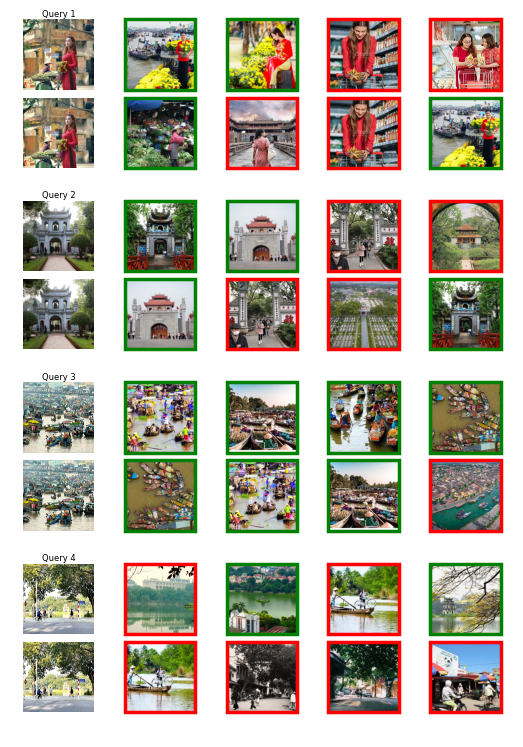

In [23]:
# Model names for labeling
model_names_i2i = ["ViSigLIP-OT", "SigLIP"]

# Whether to draw annotation borders on retrieved images
draw_annotations_i2i = True

# Set of (query_idx, model_idx, rank) tuples marking correct retrievals (green border).
# All other retrieved images get a red border when draw_annotations_i2i is True.
# query_idx: 0-based index into image_query_files
# model_idx: 0 = ViSigLIP-OT, 1 = SigLIP
# rank: 0-based rank in top-k results (0 = highest similarity, excludes query image itself)
correct_retrievals_i2i: set[tuple[int, int, int]] = {
    (0, 0, 0),
    (0, 0, 1),
    (0, 1, 0),
    (0, 1, 3),
    (1, 0, 0),
    (1, 0, 1),
    (1, 1, 0),
    (1, 1, 3),
    (2, 0, 0),
    (2, 0, 1),
    (2, 0, 2),
    (2, 0, 3),
    (2, 1, 0),
    (2, 1, 1),
    (2, 1, 2),
    (3, 0, 1),
    (3, 0, 3),
}

num_image_queries = len(image_query_files)
top_k_i2i = 4  # number of retrieved images (excluding query)
total_cols = top_k_i2i + 1  # query image + top-k retrieved

# Figure dimensions for elsarticle preprint
fig_width_i2i = 6.5
img_aspect_ratio_i2i = 1.0
img_width_i2i = fig_width_i2i / total_cols
img_height_i2i = (
    img_width_i2i / img_aspect_ratio_i2i * 0.8
)  # reduced height to fit 2 model rows per query
query_text_space_i2i = 0.25  # space for query text below images

# 3 rows per query: model 1 images, model 2 images, query text
rows_per_query_i2i = 3
height_ratios_per_query_i2i = [img_height_i2i, img_height_i2i, query_text_space_i2i]
fig_height_i2i = (img_height_i2i * 2 + query_text_space_i2i) * num_image_queries

fig_i2i = plt.figure(figsize=(fig_width_i2i, fig_height_i2i))
gs_i2i = GridSpec(
    num_image_queries * rows_per_query_i2i,
    total_cols,  # 3 rows per query: model1, model2, text
    figure=fig_i2i,
    height_ratios=height_ratios_per_query_i2i * num_image_queries,
    hspace=0.15,
    wspace=0.05,
)

for query_row, query_idx in enumerate(range(num_image_queries)):
    # Load query image once (shared by both models)
    query_image_path = image_query_file_paths[query_idx]
    query_image = mpimg.imread(query_image_path)

    # Center crop query image to square
    h, w = query_image.shape[:2]
    min_dim = min(h, w)
    start_h = (h - min_dim) // 2
    start_w = (w - min_dim) // 2
    cropped_query = query_image[start_h : start_h + min_dim, start_w : start_w + min_dim]

    # Display results for each model
    for model_idx in range(2):
        similarities = logits_i2i[model_idx][query_idx]

        # Get top-k indices sorted by decreasing similarity (exclude self if in dataset)
        top_k_indices = torch.argsort(similarities, descending=True)[: top_k_i2i + 1]
        top_k_scores = similarities[top_k_indices]

        # Calculate the grid row for this model's images
        grid_row = query_row * rows_per_query_i2i + model_idx

        # Display query image in first column (no annotation border — it's the query, not a retrieval)
        ax_query = fig_i2i.add_subplot(gs_i2i[grid_row, 0])
        ax_query.imshow(cropped_query)
        ax_query.axis("off")
        if model_idx == 0:
            ax_query.set_title(f"Query {query_row + 1}", fontsize=6, pad=2)
        # rect_query = patches.Rectangle(
        #     (0, 0), 1, 1,
        #     linewidth=2,
        #     edgecolor="blue",
        #     facecolor="none",
        #     transform=ax_query.transAxes,
        #     clip_on=False,
        # )
        # ax_query.add_patch(rect_query)

        # Display top-k retrieved images
        col_offset = 1
        results_shown = 0
        for img_idx, score in zip(top_k_indices, top_k_scores, strict=True):
            if results_shown >= top_k_i2i:
                break
            img_idx = img_idx.item()

            # Get the image from dataset
            image_path = test_dataset.samples[all_sample_image_indices[img_idx]][1]  # pyright: ignore

            # Skip if same as query image
            if os.path.basename(image_path) == image_query_files[query_idx]:
                continue

            image = mpimg.imread(image_path)

            ax = fig_i2i.add_subplot(gs_i2i[grid_row, col_offset + results_shown])

            # Center crop image to square
            h, w = image.shape[:2]
            min_dim = min(h, w)
            start_h = (h - min_dim) // 2
            start_w = (w - min_dim) // 2
            cropped_image = image[start_h : start_h + min_dim, start_w : start_w + min_dim]

            ax.imshow(cropped_image)
            ax.axis("off")

            # Draw colored border: green if correct, red otherwise.
            # Uses a Rectangle patch since ax.axis("off") suppresses spine rendering.
            if draw_annotations_i2i:
                border_color = (
                    "green"
                    if (query_idx, model_idx, results_shown) in correct_retrievals_i2i
                    else "red"
                )
                rect = patches.Rectangle(
                    (0, 0),
                    1,
                    1,
                    linewidth=2.5,
                    edgecolor=border_color,
                    facecolor="none",
                    transform=ax.transAxes,
                    clip_on=False,
                )
                ax.add_patch(rect)

            results_shown += 1

    # Create a spanning axes for query text below both model rows
    text_grid_row = query_row * rows_per_query_i2i + 2
    ax_text = fig_i2i.add_subplot(gs_i2i[text_grid_row, :])
    ax_text.axis("off")

plt.savefig("i2i_retrieval_examples_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()